# Comparação de Modelos: MLP vs Baselines

Este notebook compara o desempenho de:
1. **DummyClassifier**: Baseline trivial
2. **LogisticRegression**: Baseline linear
3. **MLPClassifier**: Rede neural em PyTorch

## Métricas Utilizadas
- **Accuracy**: Acurácia geral
- **Precision**: Taxa de acertos entre os positivos previstos
- **Recall**: Taxa de acertos entre os positivos reais
- **F1-score**: Média harmônica de precision e recall
- **ROC-AUC**: Área sob a curva ROC
- **PR-AUC**: Área sob a curva Precision-Recall
- **Cost Saved**: Economia em reais ($) evitando churns
- **ROI**: Retorno sobre investimento

In [1]:
import logging
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from projeto_ml import train, data as data_mod, features as features_mod, eval as eval_mod
from sklearn.model_selection import StratifiedKFold

logging.basicConfig(level=logging.INFO)
LOGGER = logging.getLogger(__name__)

# Configurar estilo de plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

notebook_dir = Path.cwd()
project_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir
os.chdir(project_root)

print(f"Working directory: {os.getcwd()}")
print(f"Dataset path exists: {Path('data/raw/Telco_customer_churn(Telco_Churn).csv').exists()}")

Working directory: c:\felipe\fiap\pytorch-churn-classifier
Dataset path exists: True


## 1. Carregar e Preparar Dados

In [2]:
# Carregar dados
dataset_path = "data/raw/Telco_customer_churn(Telco_Churn).csv"
df = data_mod.load_telco_churn(dataset_path, drop_leakage=True)

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df[data_mod.TARGET_COLUMN].value_counts())
print(f"\nClass balance: {df[data_mod.TARGET_COLUMN].value_counts(normalize=True).to_dict()}")

INFO:projeto_ml.data:dataset_loaded


Dataset shape: (7043, 25)

Class distribution:
Churn Value
0    5174
1    1869
Name: count, dtype: int64

Class balance: {0: 0.7346301292063041, 1: 0.2653698707936959}


## 2. Executar Treinamento com Todos os Modelos

In [3]:
# Treinar todos os modelos
LOGGER.info("Iniciando treinamento com todos os modelos...")
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from scripts.start_mlflow import start_mlflow

start_mlflow()
result = train.train(
    dataset_path=dataset_path,
    model_out=Path("models/all_models_final.joblib"),
    n_splits=5,
    metric="roc_auc",
    cost_per_churn=100.0,
    intervention_success=0.5,
    models=["dummy", "logistic", "mlp"],
)

for key, value in sorted(result['metrics'].items()):
    print(f"  {key}: {value}")

LOGGER.info("Treinamento concluído!")
print("\nResultados:")


# for key, value in sorted(result['metrics'].items()):
#     print(f"  {key}: {value:.6f}")

INFO:__main__:Iniciando treinamento com todos os modelos...


Iniciando MLflow...
MLflow iniciado com sucesso.


INFO:projeto_ml.data:dataset_loaded
INFO:projeto_ml.train:start_fold
C:\Users\fetic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\fetic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\fetic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\Lo

🏃 View run train_20260630_220308 at: http://127.0.0.1:5000/#/experiments/1/runs/45a87779dded48f6b3273a27b3fa5fe3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
  dummy_accuracy: [0.7345635202271115, 0.7345635202271115, 0.7345635202271115, 0.734375, 0.7350852272727273]
  dummy_benefit_tp: [0.0, 0.0, 0.0, 0.0, 0.0]
  dummy_cost_fn: [37400.0, 37400.0, 37400.0, 37400.0, 37300.0]
  dummy_cost_fp: [0.0, 0.0, 0.0, 0.0, 0.0]
  dummy_cost_saved: [0.0, 0.0, 0.0, 0.0, 0.0]
  dummy_f1: [0.0, 0.0, 0.0, 0.0, 0.0]
  dummy_pr_auc: [0.2654364797728886, 0.2654364797728886, 0.2654364797728886, 0.265625, 0.2649147727272727]
  dummy_precision: [0.0, 0.0, 0.0, 0.0, 0.0]
  dummy_recall: [0.0, 0.0, 0.0, 0.0, 0.0]
  dummy_roc_auc: [0.5, 0.5, 0.5, 0.5, 0.5]
  dummy_roi: [0.0, 0.0, 0.0, 0.0, 0.0]
  dummy_total_cost: [37400.0, 37400.0, 37400.0, 37400.0, 37300.0]
  logistic_accuracy: [0.8090844570617459, 0.7977288857345636, 0.8161816891412349, 0.7997159090909091, 0.7990056818181818]
  logistic_benefit

## 3. Agregar Resultados por Modelo

In [4]:
# Organizar resultados por modelo usando uma única lista de modelos e métricas
from math import ceil

MODEL_ORDER = ["dummy", "logistic", "mlp"]
METRIC_ORDER = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "cost_saved"]

metrics_by_model = {}
for key, values in result['metrics'].items():
    for model in MODEL_ORDER:
        prefix = model + "_"
        if key.startswith(prefix):
            metric_name = key[len(prefix):]
            metrics_by_model.setdefault(model, {})[metric_name] = values
            break


def _metric_display_name(metric_name):
    return metric_name.replace("_", " ").upper()


def _metric_mean(metrics, metric_name):
    values = metrics.get(metric_name, [np.nan])
    if isinstance(values, (list, tuple, np.ndarray)):
        return float(np.nanmean(values))
    return float(values)


def build_comparison_table(metrics_by_model, metric_order):
    comparison_data = []
    for model_name in MODEL_ORDER:
        metrics = metrics_by_model.get(model_name, {})
        row = {"Model": model_name.upper()}
        for metric_name in metric_order:
            value = _metric_mean(metrics, metric_name)
            row[_metric_display_name(metric_name)] = f"{value:.4f}" if metric_name != "cost_saved" else f"{value:.2f}"
        comparison_data.append(row)
    return pd.DataFrame(comparison_data)


def build_best_model_table(metrics_by_model, metric_order):
    best_rows = []
    for metric_name in metric_order:
        best_model = None
        best_value = -np.inf
        for model_name in MODEL_ORDER:
            metrics = metrics_by_model.get(model_name, {})
            if metric_name in metrics:
                value = _metric_mean(metrics, metric_name)
                if value > best_value:
                    best_value = value
                    best_model = model_name
        best_rows.append(
            {
                "Metric": _metric_display_name(metric_name),
                "Best Model": best_model.upper() if best_model else "N/A",
                "Value": f"{best_value:.4f}" if metric_name != "cost_saved" else f"{best_value:.2f}",
            }
        )
    return pd.DataFrame(best_rows)


def plot_metric_grid(metrics_by_model, metric_order):
    ncols = 4
    nrows = ceil(len(metric_order) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for idx, metric_name in enumerate(metric_order):
        ax = axes[idx]
        plot_rows = []
        for model_name in MODEL_ORDER:
            metrics = metrics_by_model.get(model_name, {})
            if metric_name in metrics:
                plot_rows.append(
                    {
                        "Model": model_name.upper(),
                        "Valor": _metric_mean(metrics, metric_name),
                    }
                )

        plot_df = pd.DataFrame(plot_rows)
        sns.barplot(
            data=plot_df,
            x="Model",
            y="Valor",
            hue="Model",
            palette="Set2",
            legend=False,
            ax=ax,
        )
        ax.set_title(_metric_display_name(metric_name))
        ax.grid(axis="y", alpha=0.3)
        if metric_name != "cost_saved":
            ax.set_ylim(0, 1)

    for idx in range(len(metric_order), len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.savefig("models/comparison_metrics.png", dpi=300, bbox_inches="tight")
    plt.show()


## 4. Tabela Comparativa Final

In [5]:
# Criar tabela com todas as métricas em uma única estrutura reutilizável
df_comparison = build_comparison_table(metrics_by_model, METRIC_ORDER)
print("\n" + "=" * 100)
print("COMPARAÇÃO FINAL DE MODELOS")
print("=" * 100)
print(df_comparison.to_string(index=False))
print("=" * 100)



COMPARAÇÃO FINAL DE MODELOS
   Model ACCURACY PRECISION RECALL     F1 ROC AUC PR AUC COST SAVED
   DUMMY   0.7346    0.0000 0.0000 0.0000  0.5000 0.2654       0.00
LOGISTIC   0.8043    0.6517 0.5650 0.6051  0.8474 0.6485   21954.00
     MLP   0.8063    0.6453 0.6046 0.6230  0.8525 0.6623   23370.00


## 5. Visualização de Métricas

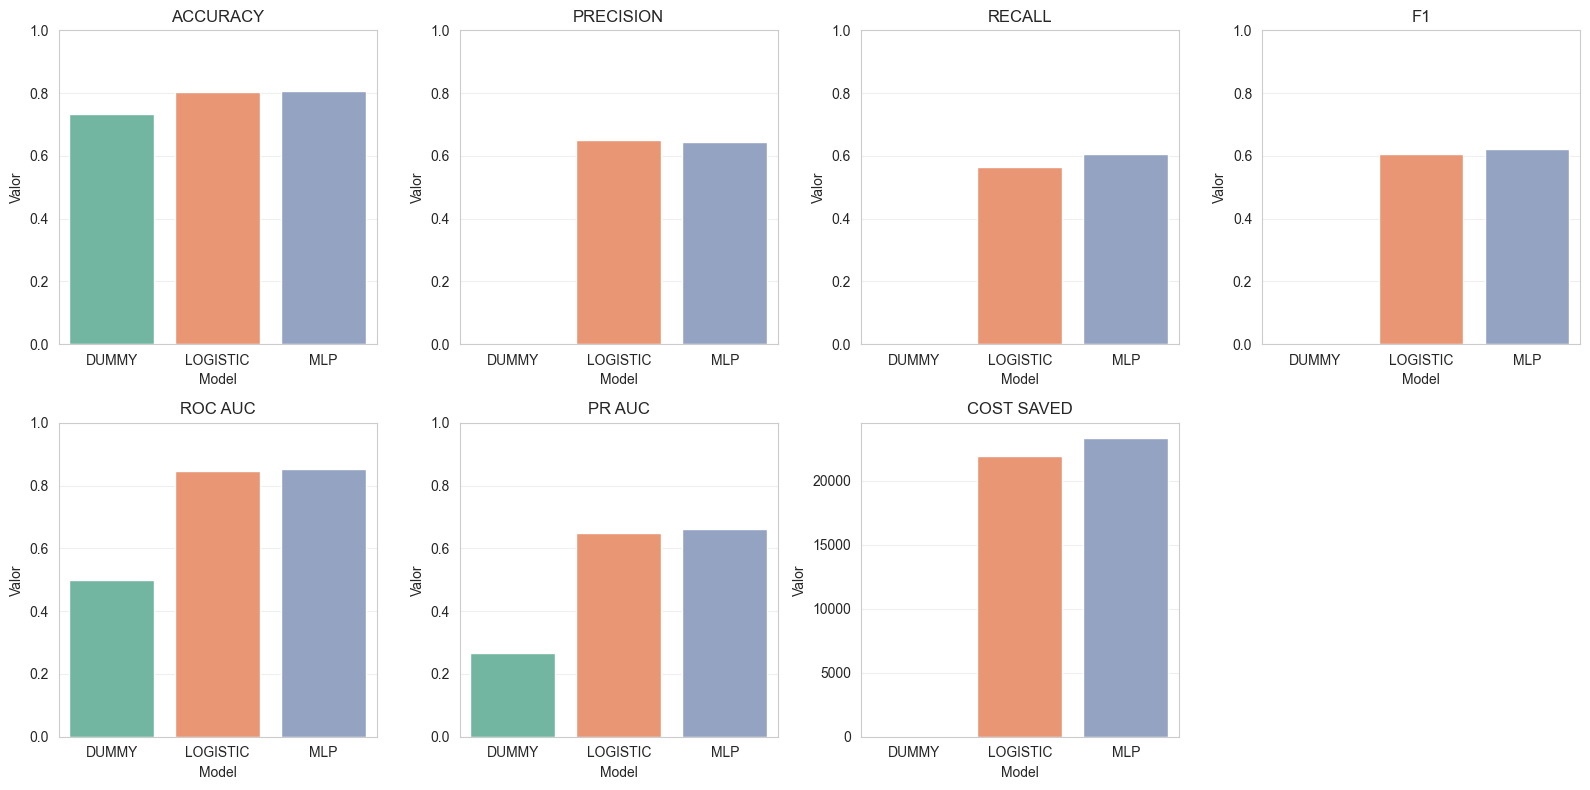

In [6]:
# Gerar gráfico para todas as métricas em uma única grade reutilizando a mesma ordem de métricas
plot_metric_grid(metrics_by_model, METRIC_ORDER)


## 6. Análise de Custo-Benefício


Análise de Custo Salvo ($):
   Model  Cost Saved (Mean)  Cost Saved (Std)  Cost Saved (Min)  Cost Saved (Max)
   DUMMY                0.0          0.000000               0.0               0.0
LOGISTIC            21954.0        777.318468           20670.0           22800.0
     MLP            23370.0       1925.710259           21150.0           25680.0

Plot salvo em: models/cost_analysis.png


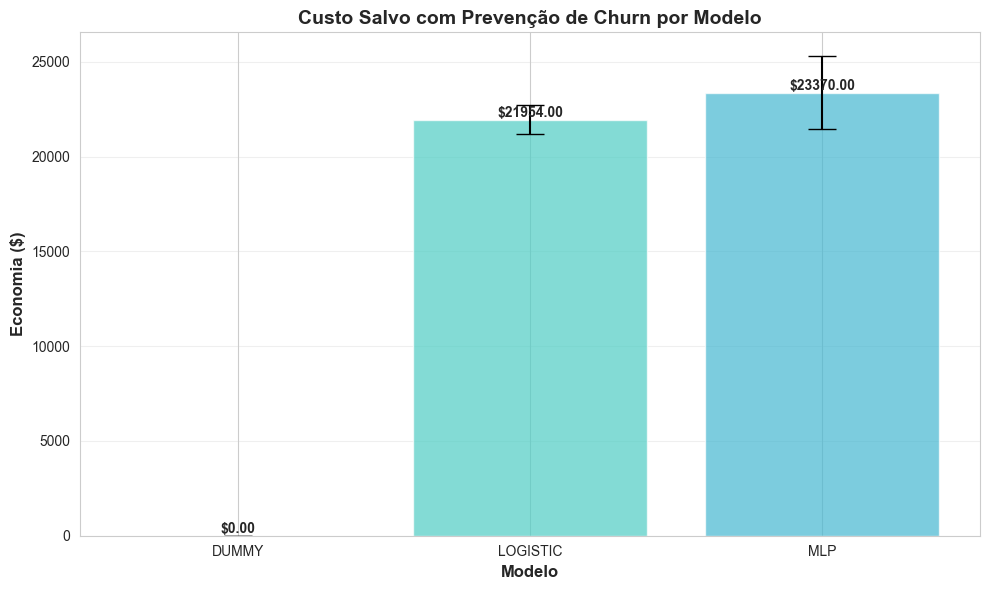

In [7]:
# Análise de custo salvo por modelo
cost_data = []

for model_name, metrics in metrics_by_model.items():
    if 'cost_saved' in metrics:
        cost_data.append({
            'Model': model_name.upper(),
            'Cost Saved (Mean)': np.nanmean(metrics['cost_saved']),
            'Cost Saved (Std)': np.nanstd(metrics['cost_saved']),
            'Cost Saved (Min)': np.nanmin(metrics['cost_saved']),
            'Cost Saved (Max)': np.nanmax(metrics['cost_saved']),
        })

df_cost = pd.DataFrame(cost_data)
print("\nAnálise de Custo Salvo ($):")
print(df_cost.to_string(index=False))

# Plot: Comparação de economia
fig, ax = plt.subplots(figsize=(10, 6))
models = df_cost['Model'].values
means = df_cost['Cost Saved (Mean)'].values
stds = df_cost['Cost Saved (Std)'].values

bars = ax.bar(models, means, yerr=stds, capsize=10, alpha=0.7, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_ylabel('Economia ($)', fontsize=12, fontweight='bold')
ax.set_xlabel('Modelo', fontsize=12, fontweight='bold')
ax.set_title('Custo Salvo com Prevenção de Churn por Modelo', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bar, mean in zip(bars, means):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${mean:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('models/cost_analysis.png', dpi=300, bbox_inches='tight')
print("\nPlot salvo em: models/cost_analysis.png")
plt.show()

## 7. Conclusões e Recomendações

In [8]:
# Identificar o melhor modelo por métrica com a mesma ordem usada na tabela e nos gráficos
df_best_models = build_best_model_table(metrics_by_model, METRIC_ORDER)
print("\n" + "=" * 100)
print("MELHOR MODELO POR MÉTRICA")
print("=" * 100)
print(df_best_models.to_string(index=False))
print("=" * 100)



MELHOR MODELO POR MÉTRICA
    Metric Best Model    Value
  ACCURACY        MLP   0.8063
 PRECISION   LOGISTIC   0.6517
    RECALL        MLP   0.6046
        F1        MLP   0.6230
   ROC AUC        MLP   0.8525
    PR AUC        MLP   0.6623
COST SAVED        MLP 23370.00


## 8. Salvar Tabela Comparativa

In [9]:
# Salvar tabela comparativa em CSV
output_path = Path("models/model_comparison_results.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

# Criar DataFrame detalhado
detailed_results = []

for model_name, metrics in metrics_by_model.items():
    for metric_name in metrics.keys():
        values = metrics[metric_name]
        detailed_results.append({
            'Model': model_name.upper(),
            'Metric': metric_name,
            'Mean': np.nanmean(values),
            'Std': np.nanstd(values),
            'Min': np.nanmin(values),
            'Max': np.nanmax(values),
        })

df_detailed = pd.DataFrame(detailed_results)
df_detailed.to_csv(output_path, index=False)

print(f"Tabela comparativa salva em: {output_path}")
print(f"\nResultados salvos:")
print(df_detailed.to_string(index=False))

Tabela comparativa salva em: models\model_comparison_results.csv

Resultados salvos:
   Model     Metric         Mean         Std          Min          Max
   DUMMY   accuracy     0.734630    0.000239     0.734375     0.735085
   DUMMY  precision     0.000000    0.000000     0.000000     0.000000
   DUMMY     recall     0.000000    0.000000     0.000000     0.000000
   DUMMY         f1     0.000000    0.000000     0.000000     0.000000
   DUMMY    roc_auc     0.500000    0.000000     0.500000     0.500000
   DUMMY     pr_auc     0.265370    0.000239     0.264915     0.265625
   DUMMY    cost_fn 37380.000000   40.000000 37300.000000 37400.000000
   DUMMY    cost_fp     0.000000    0.000000     0.000000     0.000000
   DUMMY benefit_tp     0.000000    0.000000     0.000000     0.000000
   DUMMY cost_saved     0.000000    0.000000     0.000000     0.000000
   DUMMY total_cost 37380.000000   40.000000 37300.000000 37400.000000
   DUMMY        roi     0.000000    0.000000     0.000000     0